In [14]:
import io
import json
import os
import zipfile
from glob import glob
from pathlib import Path

import numpy as np
import pydicom
import cv2
from tqdm import tqdm

import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", figsize=(6,6), vmin=None, vmax=None):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.show()

def overlay_mask(img_u8, mask_u8, alpha=0.35):
    """
    img_u8: (H,W) uint8
    mask_u8: (H,W) uint8 (0/255)
    returns: (H,W,3) uint8
    """
    if img_u8.ndim != 2:
        raise ValueError(f"Expected grayscale img_u8 (H,W), got shape {img_u8.shape}")
    if mask_u8.shape != img_u8.shape:
        raise ValueError(f"mask_u8 shape {mask_u8.shape} must match img_u8 shape {img_u8.shape}")

    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB).astype(np.float32)

    # red overlay
    red = img_rgb.copy()
    red[..., 0] = 255  # R
    red[..., 1] = 0    # G
    red[..., 2] = 0    # B

    m2 = (mask_u8 > 0)  # (H,W) boolean

    out = img_rgb.copy()
    out[m2] = alpha * red[m2] + (1 - alpha) * img_rgb[m2]
    return out.astype(np.uint8)

def invert_if_needed(pixels, dicom):
    return (pixels.max() - pixels) if getattr(dicom, "PhotometricInterpretation", "") == "MONOCHROME1" else pixels

In [15]:
INPUT_DIR = "/home/felipe/spr-mmg-1"

dicom_files = glob(os.path.join(INPUT_DIR, "**", "*.dcm"), recursive=True)
dicom_files.sort()

print("Found:", len(dicom_files), "DICOMs")
example_path = dicom_files[0] if dicom_files else None
print("Example:", example_path)

Found: 6731 DICOMs
Example: /home/felipe/spr-mmg-1/003773/1.2.840.12345.25794236842229395113762698602107838899754107258248.dcm


Shape: (4096, 3328) dtype: float32
Photometric: MONOCHROME2
Slope/Intercept: 1.0 0.0


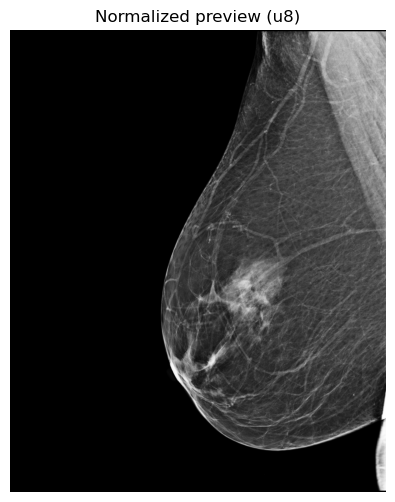

In [16]:
dcm = pydicom.dcmread(example_path, force=True)
raw = dcm.pixel_array.astype(np.float32)

slope = float(getattr(dcm, "RescaleSlope", 1.0))
intercept = float(getattr(dcm, "RescaleIntercept", 0.0))

img = raw * slope + intercept
img = invert_if_needed(img, dcm)

H, W = img.shape[:2]
print("Shape:", img.shape, "dtype:", img.dtype)
print("Photometric:", getattr(dcm, "PhotometricInterpretation", ""))
print("Slope/Intercept:", slope, intercept)


view_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
show(view_u8, "Normalized preview (u8)")

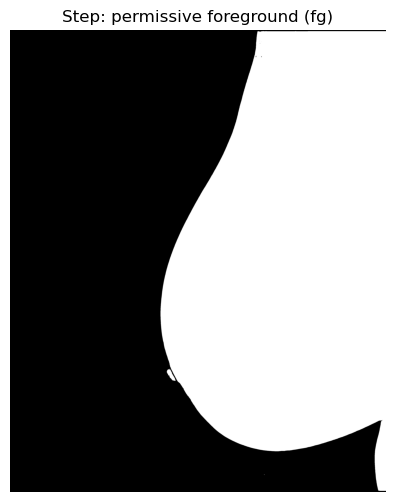

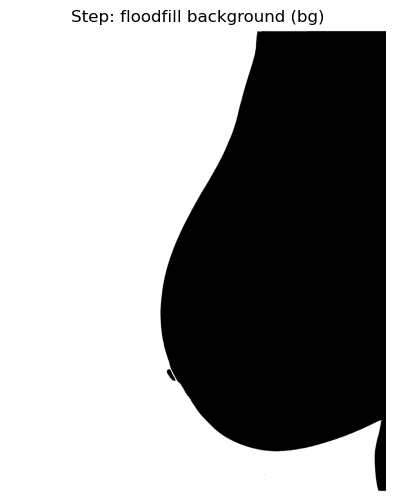

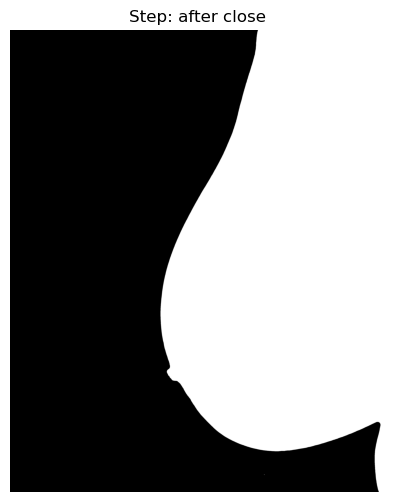

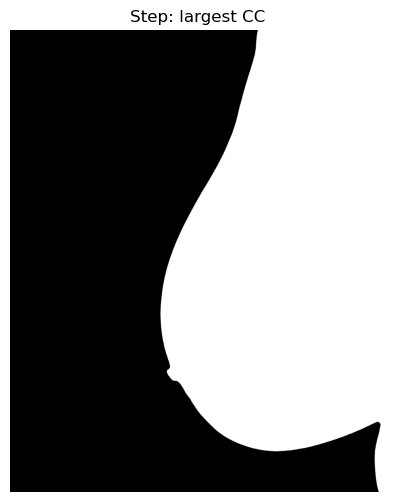

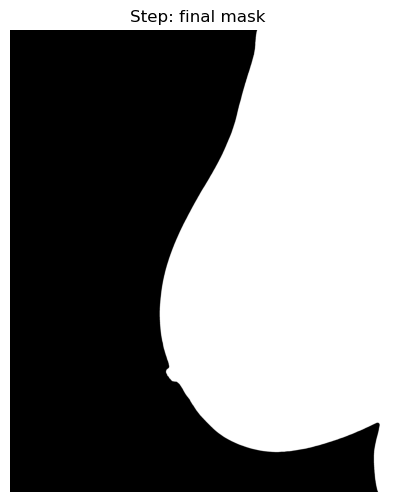

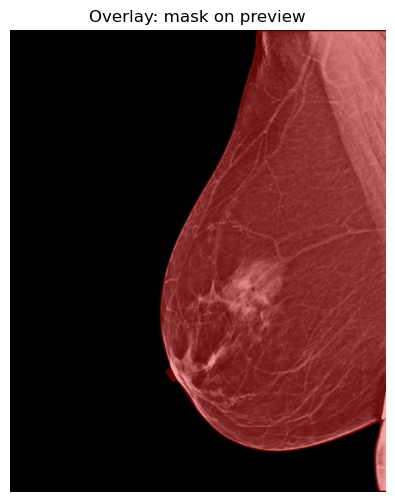

In [8]:
def create_breast_mask_u8(image_u8, debug=False):
    """
    Robust breast silhouette mask (handles implants better than Otsu).
    Returns: mask_u8 (0/255). If debug=True, also returns a dict of intermediates.
    """
    dbg = {}
    img = image_u8.copy()

    # 1) smooth a bit
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    dbg["blur"] = img_blur

    # 2) permissive foreground: anything not near-black
    _, fg = cv2.threshold(img_blur, 5, 255, cv2.THRESH_BINARY)
    dbg["fg"] = fg

    h, w = fg.shape

    # 3) background via flood-fill on inverted fg
    inv = cv2.bitwise_not(fg)
    dbg["inv_fg"] = inv

    bg = np.zeros_like(inv)
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)

    seeds = [(0, 0), (w - 1, 0), (0, h - 1), (w - 1, h - 1)]
    for sx, sy in seeds:
        if inv[sy, sx] == 255:
            tmp = inv.copy()
            flood_mask[:] = 0
            cv2.floodFill(tmp, flood_mask, (sx, sy), 128)
            bg |= ((tmp == 128).astype(np.uint8) * 255)

    dbg["bg_from_floodfill"] = bg

    # 4) breast = not background
    breast = cv2.bitwise_not(bg)
    dbg["breast_initial"] = breast

    # 5) close gaps
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
    breast_closed = cv2.morphologyEx(breast, cv2.MORPH_CLOSE, k_close)
    dbg["breast_closed"] = breast_closed

    # 6) keep largest connected component
    n, labels, stats, _ = cv2.connectedComponentsWithStats((breast_closed > 0).astype(np.uint8), connectivity=8)
    breast_largest = breast_closed.copy()
    if n > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        breast_largest = (labels == largest).astype(np.uint8) * 255
    dbg["breast_largest"] = breast_largest

    # 7) fill internal holes
    inv_b = cv2.bitwise_not(breast_largest)
    hole_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(inv_b, hole_mask, (0, 0), 128)
    holes = ((inv_b != 128).astype(np.uint8) * 255)
    breast_filled = cv2.bitwise_or(breast_largest, holes)
    dbg["holes"] = holes
    dbg["breast_filled"] = breast_filled

    # 8) small dilation
    k_dil = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    breast_final = cv2.dilate(breast_filled, k_dil, iterations=1)
    dbg["breast_final"] = breast_final

    return (breast_final, dbg) if debug else breast_final

mask_u8, dbg = create_breast_mask_u8(view_u8, debug=True)

show(dbg["fg"], "Step: permissive foreground (fg)")
show(dbg["bg_from_floodfill"], "Step: floodfill background (bg)")
show(dbg["breast_closed"], "Step: after close")
show(dbg["breast_largest"], "Step: largest CC")
show(dbg["breast_final"], "Step: final mask")

show(overlay_mask(view_u8, mask_u8), "Overlay: mask on preview", cmap=None)


BBox xywh: (1325, 0, 2003, 4096)


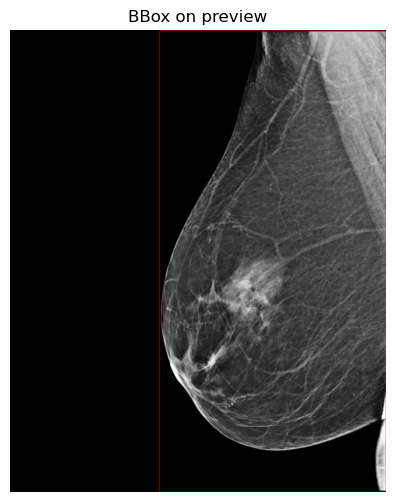

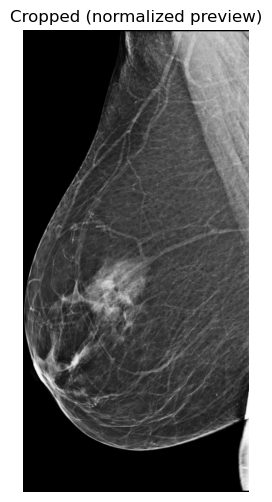

Crop shape: (4096, 2003) dtype: float32


In [9]:
def bbox_from_mask(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return (0, 0, mask.shape[1], mask.shape[0])
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    return (x, y, w, h)

x, y, w, h = bbox_from_mask(mask_u8)
print("BBox xywh:", (x, y, w, h))

# show bbox on preview
bbox_vis = cv2.cvtColor(view_u8, cv2.COLOR_GRAY2RGB)
cv2.rectangle(bbox_vis, (x, y), (x+w, y+h), (255, 0, 0), 3)
show(bbox_vis, "BBox on preview", cmap=None)

img_crop = img[y:y+h, x:x+w]
crop_u8 = cv2.normalize(img_crop, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
show(crop_u8, "Cropped (normalized preview)")
print("Crop shape:", img_crop.shape, "dtype:", img_crop.dtype)


Base window: (0.0, 3411.0)


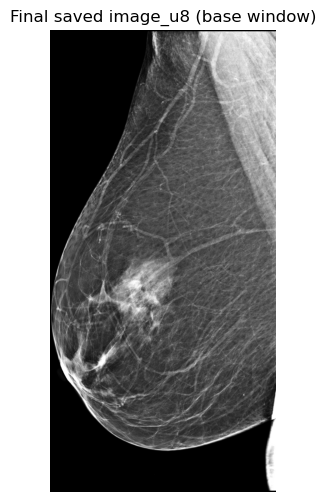

In [10]:
def window_u8(img, lo, hi):
    img = np.clip(img, lo, hi)
    out = (img - lo) / (hi - lo + 1e-6)
    return (out * 255.0).astype(np.uint8)

lo_base, hi_base = np.percentile(img_crop, 0.5), np.percentile(img_crop, 99.5)
img_u8 = window_u8(img_crop, lo_base, hi_base)

print("Base window:", (float(lo_base), float(hi_base)))
show(img_u8, "Final saved image_u8 (base window)")

In [11]:
lo1, hi1 = np.percentile(img_crop, 95), np.percentile(img_crop, 99.9)
lo2, hi2 = np.percentile(img_crop, 10), np.percentile(img_crop, 90)

manufacturer = str(getattr(dcm, "Manufacturer", "UNKNOWN")).strip() or "UNKNOWN"

meta = {
    "orig_shape": [int(H), int(W)],
    "crop_bbox_xywh": [int(x), int(y), int(w), int(h)],
    "photometric": str(getattr(dcm, "PhotometricInterpretation", "")),
    "slope": float(slope),
    "intercept": float(intercept),
    "manufacturer": manufacturer,
    "base_window": [float(lo_base), float(hi_base)],
    "window_params": {
        "ch0": [float(lo_base), float(hi_base)],
        "ch1": [float(lo1), float(hi1)],
        "ch2": [float(lo2), float(hi2)],
    },
}

print(json.dumps(meta, indent=2)[:1200], "...\n")  # truncate preview


{
  "orig_shape": [
    4096,
    3328
  ],
  "crop_bbox_xywh": [
    1325,
    0,
    2003,
    4096
  ],
  "photometric": "MONOCHROME2",
  "slope": 1.0,
  "intercept": 0.0,
  "manufacturer": "HOLOGIC, Inc.",
  "base_window": [
    0.0,
    3411.0
  ],
  "window_params": {
    "ch0": [
      0.0,
      3411.0
    ],
    "ch1": [
      2649.0,
      3973.0
    ],
    "ch2": [
      0.0,
      2120.0
    ]
  }
} ...



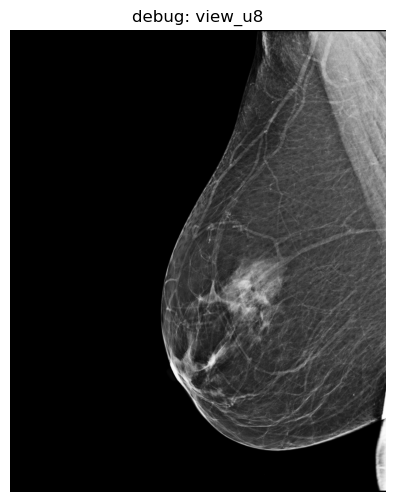

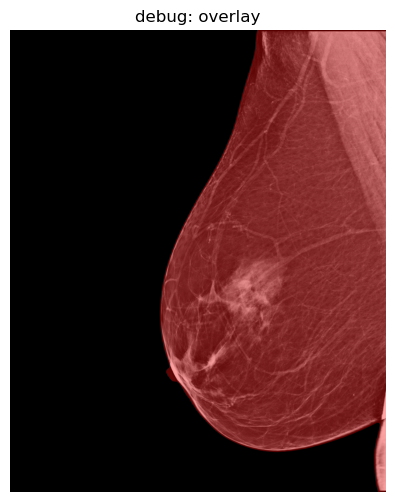

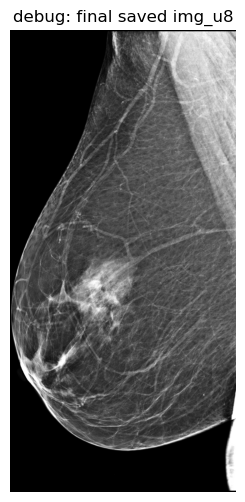

In [12]:
def create_u8_crop_and_meta(dicom_path, debug=False):
    dcm = pydicom.dcmread(dicom_path, force=True)
    raw = dcm.pixel_array.astype(np.float32)

    slope = float(getattr(dcm, "RescaleSlope", 1.0))
    intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
    img = raw * slope + intercept
    img = invert_if_needed(img, dcm)

    H, W = img.shape[:2]

    view_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if debug:
        mask_u8, dbg = create_breast_mask_u8(view_u8, debug=True)
    else:
        mask_u8 = create_breast_mask_u8(view_u8, debug=False)
        dbg = None

    x, y, w, h = bbox_from_mask(mask_u8)
    img_crop = img[y:y+h, x:x+w]

    lo_base, hi_base = np.percentile(img_crop, 0.5), np.percentile(img_crop, 99.5)
    img_u8 = window_u8(img_crop, lo_base, hi_base)

    lo1, hi1 = np.percentile(img_crop, 95), np.percentile(img_crop, 99.9)
    lo2, hi2 = np.percentile(img_crop, 10), np.percentile(img_crop, 90)

    manufacturer = str(getattr(dcm, "Manufacturer", "UNKNOWN")).strip() or "UNKNOWN"

    meta = {
        "orig_shape": [int(H), int(W)],
        "crop_bbox_xywh": [int(x), int(y), int(w), int(h)],
        "photometric": str(getattr(dcm, "PhotometricInterpretation", "")),
        "slope": slope,
        "intercept": intercept,
        "manufacturer": manufacturer,
        "base_window": [float(lo_base), float(hi_base)],
        "window_params": {
            "ch0": [float(lo_base), float(hi_base)],
            "ch1": [float(lo1), float(hi1)],
            "ch2": [float(lo2), float(hi2)],
        }
    }
    if debug:
        return img_u8, meta, {"view_u8": view_u8, "mask_u8": mask_u8, "dbg": dbg}
    return img_u8, meta

img_u8_2, meta_2, debug_pack = create_u8_crop_and_meta(example_path, debug=True)
show(debug_pack["view_u8"], "debug: view_u8")
show(overlay_mask(debug_pack["view_u8"], debug_pack["mask_u8"]), "debug: overlay", cmap=None)
show(img_u8_2, "debug: final saved img_u8")
